# 02 — Clustering: Objectives, Algorithms, and Failure Modes

Hands-on unsupervised learning with K-means from scratch and comparisons to DBSCAN and hierarchical clustering.

## Learning objectives

You will learn to:

- distinguish clustering from supervised classification;
- derive and implement the K-means update steps;
- understand inertia, initialization, and local optima;
- use elbow and silhouette diagnostics carefully;
- recognize when K-means assumptions fail;
- compare K-means, hierarchical clustering, and DBSCAN;
- evaluate clusters without confusing mathematical compactness with real-world usefulness.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs, make_moons
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score, adjusted_rand_score

rng = np.random.default_rng(42)

## 1. What clustering tries to do

Clustering partitions unlabeled observations according to a chosen notion of similarity.

Unlike classification, there is usually no unique ground-truth answer. Results depend on:

- the feature representation;
- the distance or similarity measure;
- the algorithm and its inductive bias;
- hyperparameters;
- the intended use of the groups.

Therefore, clustering is partly a modeling decision, not a machine that reveals one objectively correct partition.

## 2. K-means objective

Given points $x_1,\ldots,x_n\in\mathbb R^p$ and $K$ clusters, K-means minimizes within-cluster squared distance:

$$
J=\sum_{i=1}^{n}\|x_i-\mu_{c_i}\|_2^2,
$$

where $c_i$ is the assigned cluster and $\mu_k$ is centroid $k$.

The standard algorithm alternates:

1. **Assignment:** assign each point to its nearest centroid.
2. **Update:** replace each centroid with the mean of its assigned points.

Each step does not increase the objective, but the algorithm may converge to a local—not global—minimum.

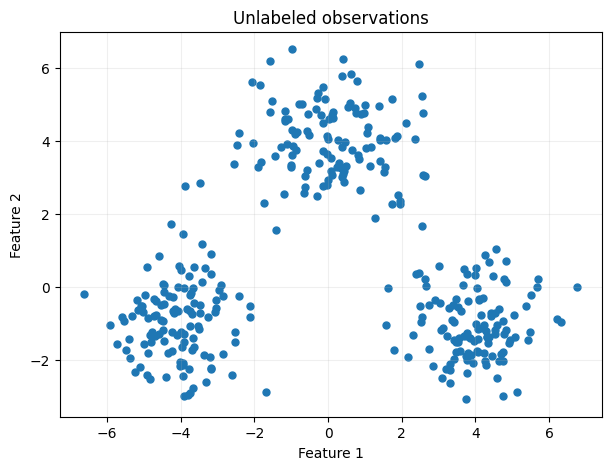

In [2]:
X, true_labels = make_blobs(
    n_samples=350,
    centers=[(-4, -1), (0, 4), (4, -1)],
    cluster_std=[1.0, 1.2, 0.9],
    random_state=42,
)

plt.figure(figsize=(7, 5))
plt.scatter(X[:, 0], X[:, 1], s=25)
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Unlabeled observations')
plt.grid(alpha=0.2)
plt.show()

## 3. K-means from scratch

The implementation below deliberately exposes the alternating steps. Production implementations add careful initialization, stopping rules, repeated restarts, and performance optimizations.

In [3]:
def kmeans_from_scratch(X, k, max_iter=100, tol=1e-6, seed=42):
    local_rng = np.random.default_rng(seed)
    initial_indices = local_rng.choice(len(X), size=k, replace=False)
    centroids = X[initial_indices].copy()
    history = [centroids.copy()]

    for _ in range(max_iter):
        squared_distances = ((X[:, None, :] - centroids[None, :, :]) ** 2).sum(axis=2)
        labels = squared_distances.argmin(axis=1)

        new_centroids = centroids.copy()
        for cluster_id in range(k):
            members = X[labels == cluster_id]
            if len(members) > 0:
                new_centroids[cluster_id] = members.mean(axis=0)
            else:
                new_centroids[cluster_id] = X[local_rng.integers(len(X))]

        history.append(new_centroids.copy())
        if np.linalg.norm(new_centroids - centroids) < tol:
            centroids = new_centroids
            break
        centroids = new_centroids

    squared_distances = ((X[:, None, :] - centroids[None, :, :]) ** 2).sum(axis=2)
    labels = squared_distances.argmin(axis=1)
    inertia = squared_distances[np.arange(len(X)), labels].sum()
    return labels, centroids, inertia, history

labels, centroids, inertia, history = kmeans_from_scratch(X, k=3)
print(f'Converged after {len(history)-1} updates; inertia={inertia:.2f}')

Converged after 4 updates; inertia=720.73


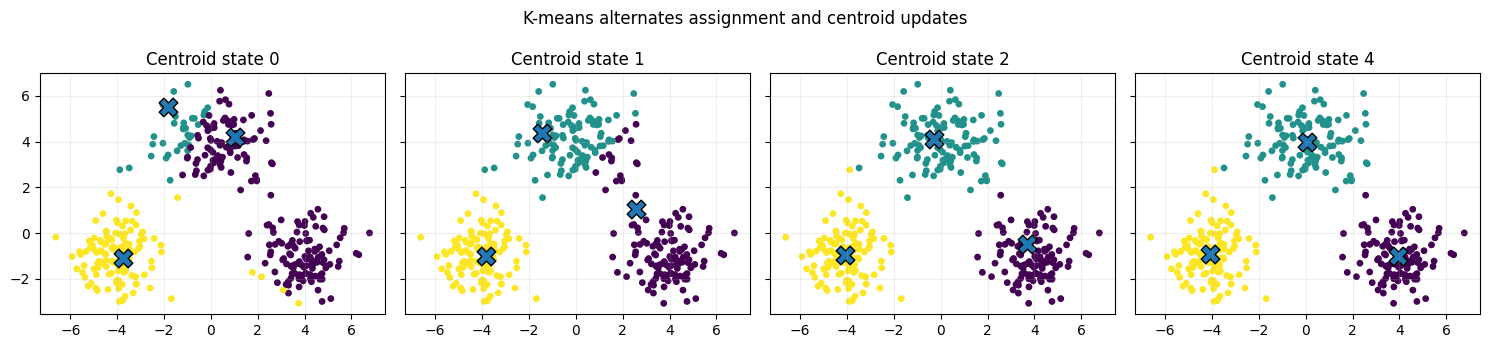

In [4]:
# Visualize early centroid movement.
steps_to_show = [0, 1, min(2, len(history)-1), len(history)-1]
fig, axes = plt.subplots(1, len(steps_to_show), figsize=(15, 3.5), sharex=True, sharey=True)

for ax, step in zip(axes, steps_to_show):
    step_centroids = history[step]
    distances = ((X[:, None, :] - step_centroids[None, :, :]) ** 2).sum(axis=2)
    step_labels = distances.argmin(axis=1)
    ax.scatter(X[:, 0], X[:, 1], c=step_labels, s=15)
    ax.scatter(step_centroids[:, 0], step_centroids[:, 1], marker='X', s=180, edgecolor='black')
    ax.set_title(f'Centroid state {step}')
    ax.grid(alpha=0.2)

plt.suptitle('K-means alternates assignment and centroid updates')
plt.tight_layout()
plt.show()

## 4. Initialization and local optima

Poor initial centroids can produce poor local solutions. **K-means++** spreads initial centroids and is the common default. Multiple initializations reduce sensitivity further.

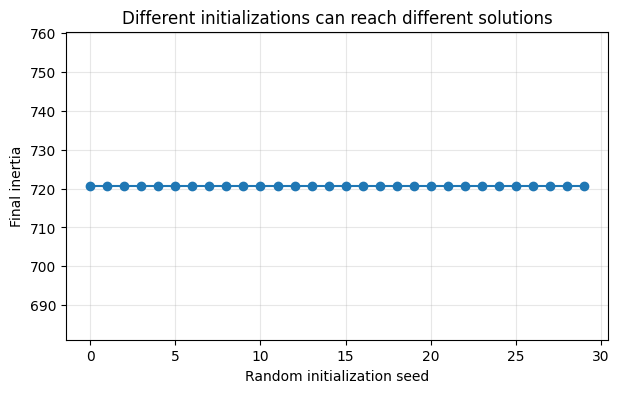

Best inertia: 720.7334117907487
Worst inertia: 720.7334117907487


In [5]:
inertias = []
for seed in range(30):
    _, _, run_inertia, _ = kmeans_from_scratch(X, k=3, seed=seed)
    inertias.append(run_inertia)

plt.figure(figsize=(7, 4))
plt.plot(range(len(inertias)), inertias, marker='o')
plt.xlabel('Random initialization seed')
plt.ylabel('Final inertia')
plt.title('Different initializations can reach different solutions')
plt.grid(alpha=0.3)
plt.show()

print('Best inertia:', min(inertias))
print('Worst inertia:', max(inertias))

## 5. Choosing the number of clusters

Two common diagnostics are:

- **Elbow curve:** inertia versus $K$;
- **Silhouette score:** compares within-cluster cohesion with nearest-cluster separation.

Neither automatically determines the “true” number of clusters. Domain usefulness and stability matter too.

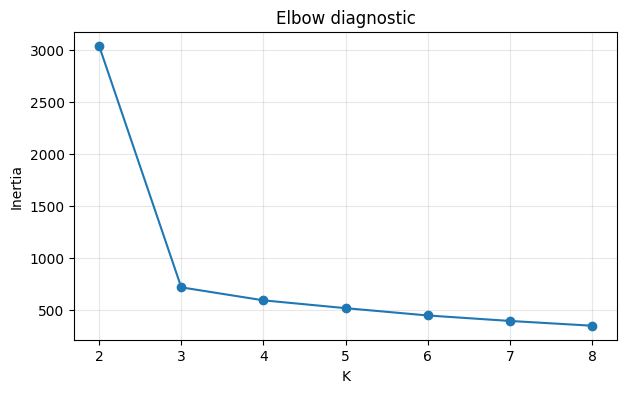

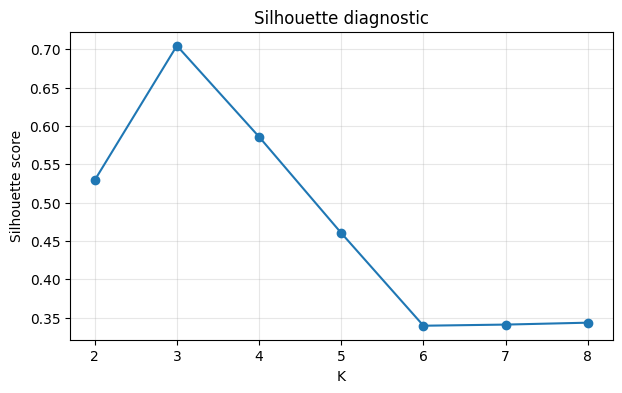

In [6]:
ks = range(2, 9)
inertia_values = []
silhouette_values = []

for k in ks:
    model = KMeans(n_clusters=k, n_init=10, random_state=42)
    labels_k = model.fit_predict(X)
    inertia_values.append(model.inertia_)
    silhouette_values.append(silhouette_score(X, labels_k))

plt.figure(figsize=(7, 4))
plt.plot(list(ks), inertia_values, marker='o')
plt.xlabel('K')
plt.ylabel('Inertia')
plt.title('Elbow diagnostic')
plt.grid(alpha=0.3)
plt.show()

plt.figure(figsize=(7, 4))
plt.plot(list(ks), silhouette_values, marker='o')
plt.xlabel('K')
plt.ylabel('Silhouette score')
plt.title('Silhouette diagnostic')
plt.grid(alpha=0.3)
plt.show()

## 6. Why scaling matters

Euclidean distance is sensitive to units. A feature measured in thousands can dominate another measured between 0 and 1.

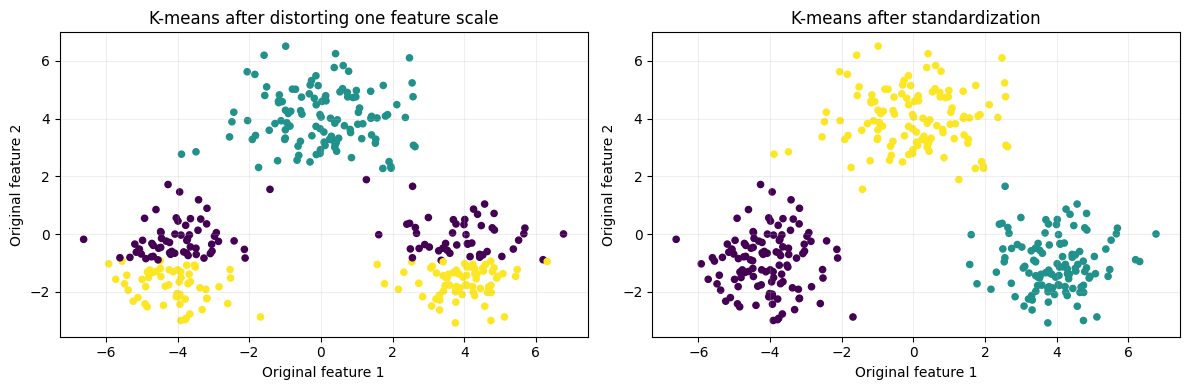

In [7]:
X_unscaled = X.copy()
X_unscaled[:, 1] *= 100

labels_unscaled = KMeans(n_clusters=3, n_init=10, random_state=42).fit_predict(X_unscaled)
labels_scaled = KMeans(n_clusters=3, n_init=10, random_state=42).fit_predict(StandardScaler().fit_transform(X_unscaled))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].scatter(X[:, 0], X[:, 1], c=labels_unscaled, s=20)
axes[0].set_title('K-means after distorting one feature scale')
axes[1].scatter(X[:, 0], X[:, 1], c=labels_scaled, s=20)
axes[1].set_title('K-means after standardization')
for ax in axes:
    ax.set_xlabel('Original feature 1')
    ax.set_ylabel('Original feature 2')
    ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

## 7. K-means assumptions and failure modes

K-means works best for clusters that are roughly:

- compact;
- convex or ball-shaped;
- similar in scale;
- separable under squared Euclidean distance.

It struggles with curved shapes, very unequal densities, severe outliers, categorical features, and clusters defined by non-Euclidean relationships.

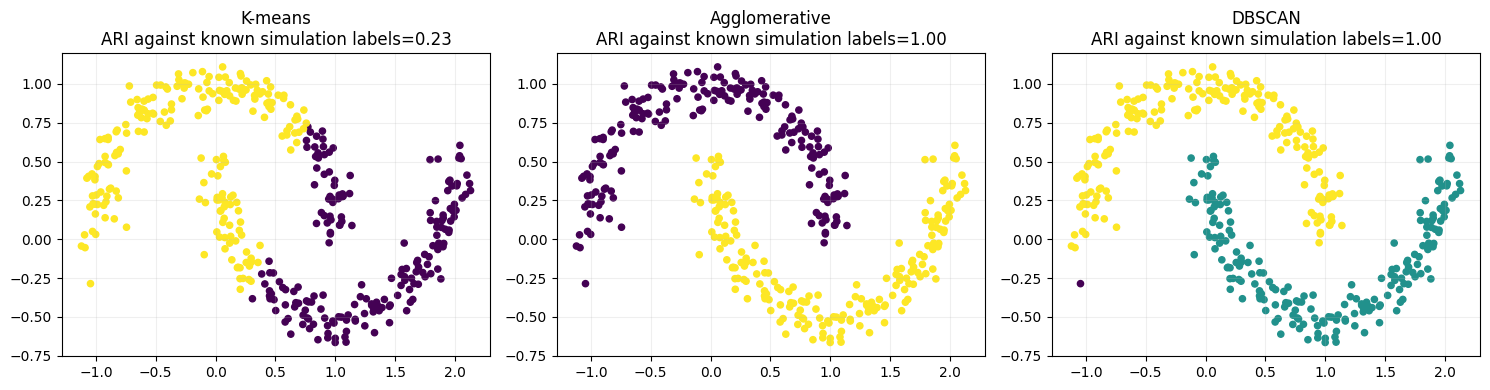

In [8]:
X_moons, moon_truth = make_moons(n_samples=400, noise=0.08, random_state=42)

algorithms = {
    'K-means': KMeans(n_clusters=2, n_init=10, random_state=42),
    'Agglomerative': AgglomerativeClustering(n_clusters=2, linkage='single'),
    'DBSCAN': DBSCAN(eps=0.20, min_samples=5),
}

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (name, algorithm) in zip(axes, algorithms.items()):
    predicted = algorithm.fit_predict(X_moons)
    ax.scatter(X_moons[:, 0], X_moons[:, 1], c=predicted, s=20)
    ari = adjusted_rand_score(moon_truth, predicted)
    ax.set_title(f'{name}\nARI against known simulation labels={ari:.2f}')
    ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

### DBSCAN

DBSCAN groups dense regions and labels isolated observations as noise. It can discover non-convex shapes and does not require $K$ in advance.

Important hyperparameters:

- `eps`: neighborhood radius;
- `min_samples`: minimum local density.

Its main difficulty is choosing a meaningful density scale, especially when cluster densities differ.

### Hierarchical clustering

Hierarchical methods build nested groupings. Agglomerative clustering starts from individual points and merges clusters according to linkage criteria. A dendrogram can help examine multiple levels, though scikit-learn's basic estimator does not itself plot one.

## 8. Cluster evaluation

When true labels exist only for a simulation or retrospective analysis, external metrics such as Adjusted Rand Index can compare partitions. In truly unsupervised work, evaluate:

1. **internal geometry:** silhouette, compactness, separation;
2. **stability:** do clusters persist under resampling or small perturbations?;
3. **interpretability:** can the cluster profiles be described?;
4. **utility:** do clusters support a real decision or downstream task?;
5. **fairness and safety:** could grouping create harmful proxies or unjustified conclusions?

A high silhouette score does not guarantee meaningful customer, biological, or linguistic categories.

## Exercises

1. Add outliers to the blob dataset and compare K-means with DBSCAN.
2. Implement K-means++ initialization from scratch.
3. Compute silhouette values for each point and inspect low-scoring observations.
4. Use cosine distance or normalized embeddings for a text-clustering experiment.
5. Bootstrap the dataset several times and measure partition stability.
6. Explain why clustering raw word-count vectors may be dominated by document length.

## Key takeaways

- Clustering depends on representation and similarity, not just the algorithm.
- K-means minimizes within-cluster squared distance through alternating updates.
- Initialization, scaling, and $K$ selection materially affect results.
- Different algorithms encode different cluster shapes.
- Mathematical compactness is evidence, not proof, of semantic usefulness.